# Phase 2: Feature Extraction & Dimensionality Reduction

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

## Load the data

In [2]:
df = pd.read_csv("/kaggle/input/datasets/marryammohammed/nasa-battery-cycle-level-dataset/NASA Battery Cycle Level Dataset.csv")
print("rows, cols:", df.shape)
print("number of batteries:", df["battery_id"].nunique())
df.head()

rows, cols: (2769, 59)
number of batteries: 34


,source_file,battery_id,test_id,uid,start_time,ambient_temperature,Capacity,Re,Rct,Voltage_measured_mean,...,Current_load_range,Voltage_load_range,Time_range,duration_seconds,cycle_number,SOH,initial_capacity,SOH_relative,RUL_cycles,health_class
0,05122.csv,B0005,1,5122,[2.0080e+03 4.0000e+00 2.0000e+00 1.5000e+01 2...,24,1.856487,NaN,NaN,3.529829,...,1.9980,4.206,3690.234,3690.234,1,0.928244,1.856487,1.000000,167,Healthy
1,05124.csv,B0005,3,5124,[2.0080e+03 4.0000e+00 2.0000e+00 1.9000e+01 4...,24,1.846327,NaN,NaN,3.537320,...,1.9978,4.204,3672.344,3672.344,2,0.923164,1.856487,0.994527,166,Healthy
2,05126.csv,B0005,5,5126,[2.008e+03 4.000e+00 3.000e+00 0.000e+00 1.000...,24,1.835349,NaN,NaN,3.543737,...,1.9980,4.203,3651.641,3651.641,3,0.917675,1.856487,0.988614,165,Healthy
3,05128.csv,B0005,7,5128,[2008. 4. 3. 4. 16. ...,24,1.835263,NaN,NaN,3.543666,...,1.9978,4.203,3631.563,3631.563,4,0.917631,1.856487,0.988567,164,Healthy
4,05130.csv,B0005,9,5130,[2008. 4. 3. 8. 33. ...,24,1.834646,NaN,NaN,3.542343,...,1.9978,4.203,3629.172,3629.172,5,0.917323,1.856487,0.988235,163,Healthy


## Feature engineering

In [3]:
# 1) how much the voltage drops during one discharge
df["volt_drop"] = df["Voltage_measured_first"] - df["Voltage_measured_last"]
# 2) speed of the voltage drop (volts per second)
df["volt_slope"] = (df["Voltage_measured_last"] - df["Voltage_measured_first"]) / df["duration_seconds"]
# 3) how much the cell heats up in a cycle
df["temp_rise"] = df["Temperature_measured_max"] - df["Temperature_measured_first"]
# 4) voltage variability inside the cycle
df["volt_cv"] = df["Voltage_measured_std"] / df["Voltage_measured_mean"]
# 5) change in discharge time vs the previous cycle of the same battery
df["duration_change"] = df.groupby("battery_id")["duration_seconds"].diff().fillna(0)
# 6) smoothed discharge time (rolling average per battery)
df["duration_smooth"] = df.groupby("battery_id")["duration_seconds"].transform(
    lambda s: s.rolling(5, min_periods=1).mean())

new_features = ["volt_drop", "volt_slope", "temp_rise", "volt_cv",
                "duration_change", "duration_smooth"]
df[new_features] = df[new_features].replace([np.inf, -np.inf], np.nan)
print("added new features:", new_features)

added new features: ['volt_drop', 'volt_slope', 'temp_rise', 'volt_cv', 'duration_change', 'duration_smooth']


In [4]:
id_cols = ["source_file", "battery_id", "test_id", "uid", "start_time"]
target_cols = ["Capacity", "SOH", "SOH_relative", "initial_capacity",
               "RUL_cycles", "health_class"]

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cols = [c for c in num_cols if c not in id_cols + target_cols]
print("features before cleaning:", len(cols))

features before cleaning: 54


## Cleaning

In [5]:
empty = [c for c in cols if df[c].isna().mean() > 0.5]
cols = [c for c in cols if c not in empty]
print("dropped empty columns:", empty)

df[cols] = df[cols].fillna(df[cols].median(numeric_only=True))

constant = [c for c in cols if df[c].std() == 0]
cols = [c for c in cols if c not in constant]
print("dropped constant columns:", constant)

dropped empty columns: ['Re', 'Rct']
dropped constant columns: ['Time_min', 'Time_first']


## correlations to drop near-duplicates

Many columns (min/max/first/last/mean of the same signal) carry almost the same
information. The heatmap shows this, then we drop one column from every pair that
is more than 95% correlated.

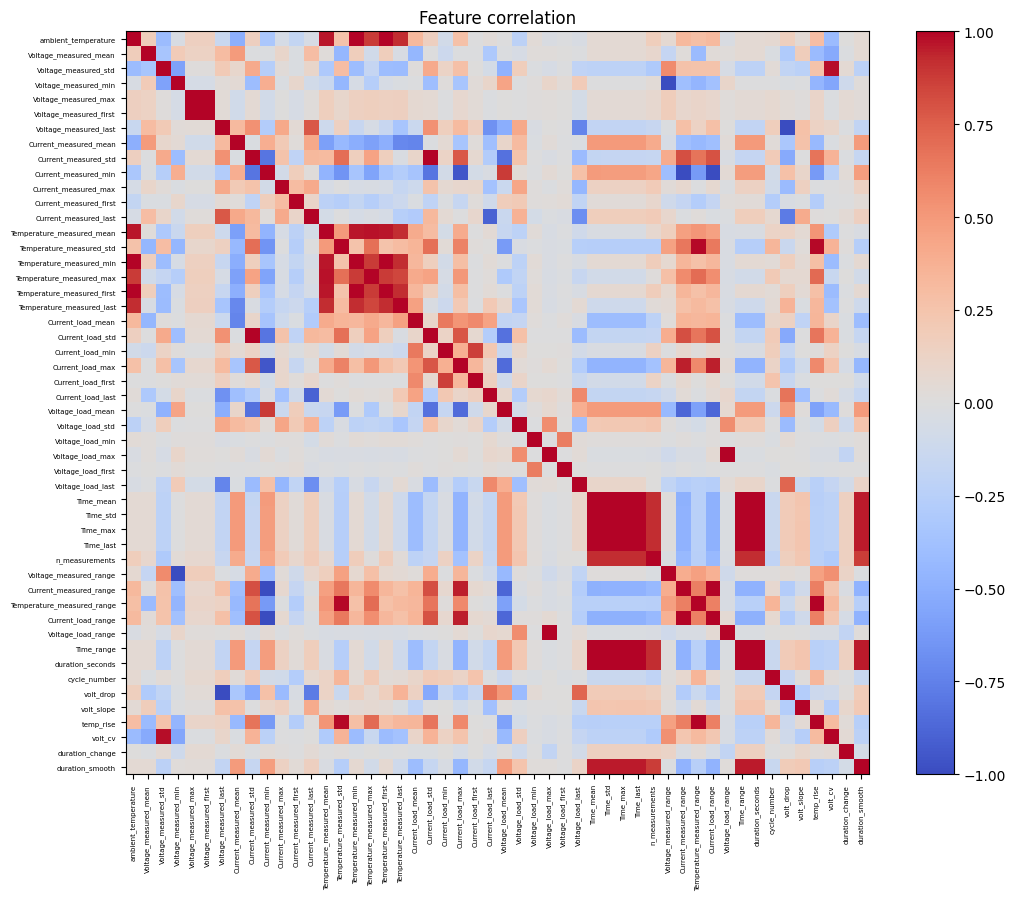

In [6]:
corr = df[cols].corr()
plt.figure(figsize=(11, 9))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(cols)), cols, rotation=90, fontsize=5)
plt.yticks(range(len(cols)), cols, fontsize=5)
plt.title("Feature correlation")
plt.tight_layout()
plt.show()

In [7]:
corr_abs = df[cols].corr().abs()
upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))
duplicate = [c for c in upper.columns if (upper[c] > 0.95).any()]
cols = [c for c in cols if c not in duplicate]
print("dropped", len(duplicate), "highly-correlated columns")
print("final number of features:", len(cols))

dropped 20 highly-correlated columns
final number of features: 30


## Scale the features

PCA is based on variance, so we standardise every feature first.

In [8]:
X = df[cols].to_numpy(dtype=float)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## PCA

In [9]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
var_ratio = pca.explained_variance_ratio_
cum_var = np.cumsum(var_ratio)
k = int(np.argmax(cum_var >= 0.95) + 1)  
print("variance kept by each PC:", np.round(var_ratio, 3))
print("number of components for 95% variance:", k)

variance kept by each PC: [0.196 0.164 0.088 0.082 0.062 0.057 0.054 0.05  0.042 0.034 0.028 0.028
 0.024 0.022 0.017 0.012 0.01  0.008 0.006 0.005 0.004 0.002 0.002 0.002
 0.001 0.001 0.001 0.    0.    0.   ]
number of components for 95% variance: 16


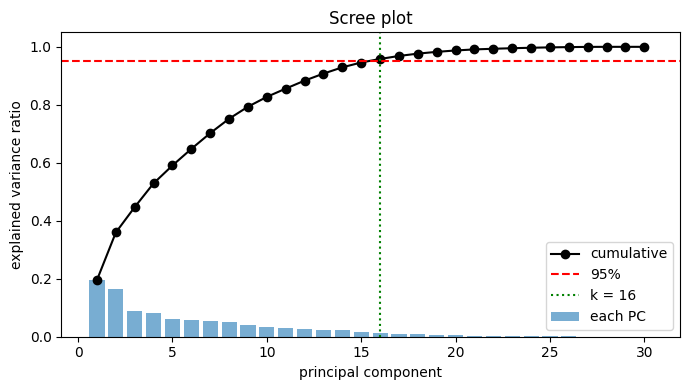

In [10]:
plt.figure(figsize=(7, 4))
x_axis = range(1, len(var_ratio) + 1)
plt.bar(x_axis, var_ratio, alpha=0.6, label="each PC")
plt.plot(x_axis, cum_var, "o-", color="black", label="cumulative")
plt.axhline(0.95, color="red", ls="--", label="95%")
plt.axvline(k, color="green", ls=":", label="k = %d" % k)
plt.xlabel("principal component")
plt.ylabel("explained variance ratio")
plt.title("Scree plot")
plt.legend()
plt.tight_layout()
plt.show()

## Which features build PC1 and PC2

In [11]:
loadings = pd.DataFrame(pca.components_[:2].T, index=cols, columns=["PC1", "PC2"])
loadings.sort_values("PC1").round(3)

,PC1,PC2
Current_measured_min,-0.373,0.016
Voltage_load_mean,-0.364,-0.104
Time_mean,-0.240,0.119
n_measurements,-0.210,0.104
Current_measured_mean,-0.183,0.315
Voltage_measured_min,-0.183,-0.050
Voltage_load_last,-0.169,-0.281
Current_measured_first,-0.080,0.077
Voltage_measured_mean,-0.080,0.155
volt_slope,-0.048,0.165


## Plot the data on the first two components

If PCA captured ageing, the SOH colour should change smoothly along PC1.

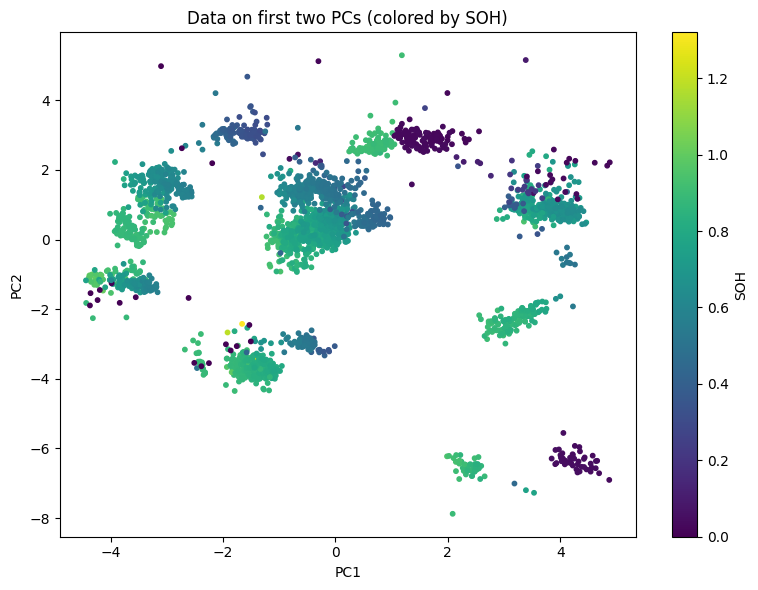

In [12]:
plt.figure(figsize=(8, 6))
sc = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["SOH"], cmap="viridis", s=10)
plt.colorbar(sc, label="SOH")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Data on first two PCs (colored by SOH)")
plt.tight_layout()
plt.show()

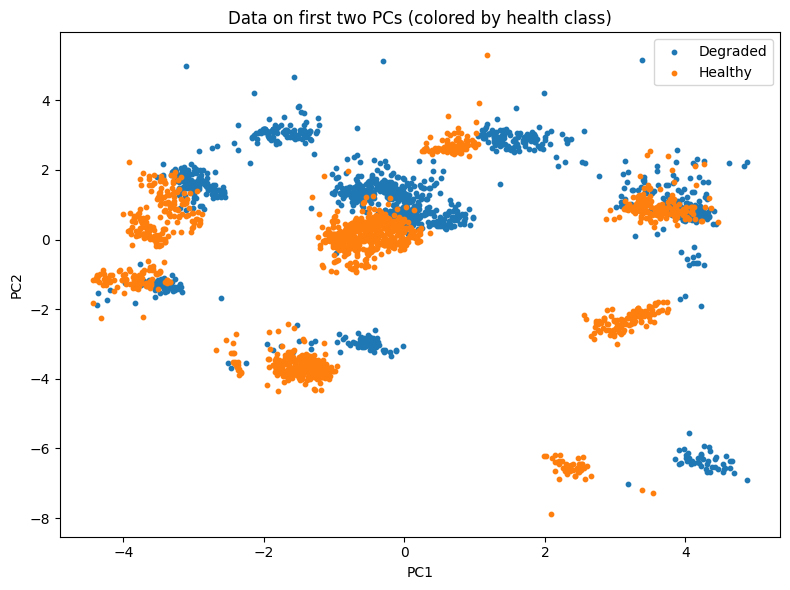

In [13]:
plt.figure(figsize=(8, 6))
health = df["health_class"].astype("category")
for name in health.cat.categories:
    m = (health == name).to_numpy()
    plt.scatter(X_pca[m, 0], X_pca[m, 1], s=10, label=str(name))
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Data on first two PCs (colored by health class)")
plt.legend()
plt.tight_layout()
plt.show()

## Save the reduced data

In [14]:
out = df[["battery_id", "cycle_number", "SOH", "RUL_cycles", "health_class"]].copy()
for i in range(k):
    out["PC%d" % (i + 1)] = X_pca[:, i]
out.head()

,battery_id,cycle_number,SOH,RUL_cycles,health_class,PC1,PC2,PC3,PC4,PC5,...,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16
0,B0005,1,0.928244,167,Healthy,-3.231000,0.885751,1.357175,-6.982016,0.768114,...,-0.635379,0.819893,0.919017,0.096724,0.085311,0.898858,0.207064,-1.580954,0.324508,-0.192676
1,B0005,2,0.923164,166,Healthy,-3.352762,1.288173,1.330302,-6.656423,1.005339,...,-1.042877,0.125932,0.310045,0.188755,-0.067593,1.001977,0.968349,-0.284740,-0.197445,-0.178254
2,B0005,3,0.917675,165,Healthy,-3.361312,1.094006,1.350029,-6.771524,1.086297,...,-0.873785,0.405573,0.585216,0.098602,0.025864,0.976257,0.621910,-0.842153,-0.230978,-0.205600
3,B0005,4,0.917631,164,Healthy,-3.285215,1.048205,1.347363,-6.862255,0.943678,...,-0.795231,0.508032,0.673083,0.097142,0.008247,0.932843,0.486023,-0.966358,0.085333,-0.187754
4,B0005,5,0.917323,163,Healthy,-3.066537,0.899574,1.440661,-7.126101,0.620169,...,-0.420297,1.150170,1.153603,-0.056927,0.009196,1.019593,0.032928,-2.083937,1.362967,-0.140645


# Phase 3 - Regression: predict SOH 

In [15]:
from sklearn.model_selection import GroupShuffleSplit, GroupKFold

y = df["SOH"].to_numpy()
groups = df["battery_id"].to_numpy()
X_all = df[cols].to_numpy(dtype=float)

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(X_all, y, groups))
X_train, X_test = X_all[train_idx], X_all[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
train_groups = groups[train_idx]

n_groups = len(set(train_groups))
gkf = GroupKFold(n_splits=min(5, n_groups))
print("train rows:", len(y_train), "| test rows:", len(y_test), "| CV folds:", gkf.get_n_splits())

train rows: 2340 | test rows: 429 | CV folds: 5


In [16]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

def show(name, cv_rmse, model):
    pred = model.predict(X_test)
    rmse = mean_squared_error(y_test, pred) ** 0.5
    mae = mean_absolute_error(y_test, pred)
    mape = np.mean(np.abs((y_test - pred) / y_test)) * 100  
    max_err = np.max(np.abs(y_test - pred))                  
    r2 = r2_score(y_test, pred)
    print("%-14s | CV RMSE=%.4f | test RMSE=%.4f | MAE=%.4f | MAPE=%.2f%% | R2=%.4f"
          % (name, cv_rmse, rmse, mae, mape, r2))
    return {"model": name, "CV_RMSE": cv_rmse, "test_RMSE": rmse, "test_MAE": mae,
            "test_MAPE": mape, "test_MaxErr": max_err, "test_R2": r2}

def grouped_cv_rmse(estimator):
    s = cross_val_score(estimator, X_train, y_train, groups=train_groups,
                        cv=gkf, scoring="neg_mean_squared_error")
    return (-s.mean()) ** 0.5

results = []

## Model 1 - Linear (plain vs Ridge-regularised)

In [17]:
from sklearn.linear_model import LinearRegression, Ridge

linear = make_pipeline(StandardScaler(), LinearRegression()).fit(X_train, y_train)
results.append(show("Linear", grouped_cv_rmse(make_pipeline(StandardScaler(), LinearRegression())), linear))

ridge_search = GridSearchCV(make_pipeline(StandardScaler(), Ridge()),
                            {"ridge__alpha": [0.1, 1, 10, 100, 1000]},
                            cv=gkf, scoring="neg_mean_squared_error")
ridge_search.fit(X_train, y_train, groups=train_groups)
ridge = ridge_search.best_estimator_
print("best ridge alpha:", ridge_search.best_params_["ridge__alpha"])
results.append(show("Ridge", (-ridge_search.best_score_) ** 0.5, ridge))

Linear         | CV RMSE=0.2835 | test RMSE=0.2471 | MAE=0.1160 | MAPE=inf% | R2=0.4096
best ridge alpha: 100
Ridge          | CV RMSE=0.0950 | test RMSE=0.2662 | MAE=0.1205 | MAPE=inf% | R2=0.3147


/tmp/ipykernel_58/2708405558.py:10: RuntimeWarning: divide by zero encountered in divide
  mape = np.mean(np.abs((y_test - pred) / y_test)) * 100   # average % error
/tmp/ipykernel_58/2708405558.py:10: RuntimeWarning: divide by zero encountered in divide
  mape = np.mean(np.abs((y_test - pred) / y_test)) * 100   # average % error


## Model 2 - Polynomial Regression (regularised, low degree)

In [18]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.decomposition import PCA

n_pcs = min(5, X_train.shape[1])
poly_pipe = make_pipeline(StandardScaler(),
                          PCA(n_components=n_pcs, random_state=42),
                          PolynomialFeatures(include_bias=False),
                          Ridge())
poly_grid = {"polynomialfeatures__degree": [1, 2], "ridge__alpha": [0.1, 1, 10, 100]}
poly_search = GridSearchCV(poly_pipe, poly_grid, cv=gkf, scoring="neg_mean_squared_error")
poly_search.fit(X_train, y_train, groups=train_groups)
poly = poly_search.best_estimator_
print("best poly params:", poly_search.best_params_)
results.append(show("Polynomial", (-poly_search.best_score_) ** 0.5, poly))

best poly params: {'polynomialfeatures__degree': 1, 'ridge__alpha': 0.1}
Polynomial     | CV RMSE=0.1344 | test RMSE=0.2199 | MAE=0.1446 | MAPE=inf% | R2=0.5323


/tmp/ipykernel_58/2708405558.py:10: RuntimeWarning: divide by zero encountered in divide
  mape = np.mean(np.abs((y_test - pred) / y_test)) * 100   # average % error


## Model 3 - Support Vector Regression (grid-searched)

In [19]:
from sklearn.svm import SVR

svr_pipe = make_pipeline(StandardScaler(), SVR(kernel="rbf"))
svr_grid = {"svr__C": [1, 10, 100], "svr__gamma": ["scale", 0.01, 0.1],
            "svr__epsilon": [0.01, 0.05, 0.1]}
svr_search = GridSearchCV(svr_pipe, svr_grid, cv=gkf,
                          scoring="neg_mean_squared_error", n_jobs=-1)
svr_search.fit(X_train, y_train, groups=train_groups)
svr = svr_search.best_estimator_
print("best SVR params:", svr_search.best_params_)
results.append(show("SVR", (-svr_search.best_score_) ** 0.5, svr))

best SVR params: {'svr__C': 1, 'svr__epsilon': 0.01, 'svr__gamma': 0.01}
SVR            | CV RMSE=0.0602 | test RMSE=0.1604 | MAE=0.0706 | MAPE=inf% | R2=0.7512


/tmp/ipykernel_58/2708405558.py:10: RuntimeWarning: divide by zero encountered in divide
  mape = np.mean(np.abs((y_test - pred) / y_test)) * 100   # average % error


## Model 4 - Random Forest

In [20]:
from sklearn.ensemble import RandomForestRegressor

rf_grid = {"n_estimators": [300], "max_depth": [None, 8, 16], "min_samples_leaf": [1, 3]}
rf_search = GridSearchCV(RandomForestRegressor(random_state=42, n_jobs=-1),
                         rf_grid, cv=gkf, scoring="neg_mean_squared_error")
rf_search.fit(X_train, y_train, groups=train_groups)
rf = rf_search.best_estimator_
print("best RF params:", rf_search.best_params_)
results.append(show("Random Forest", (-rf_search.best_score_) ** 0.5, rf))

best RF params: {'max_depth': 16, 'min_samples_leaf': 3, 'n_estimators': 300}
Random Forest  | CV RMSE=0.0805 | test RMSE=0.1231 | MAE=0.0618 | MAPE=inf% | R2=0.8535


/tmp/ipykernel_58/2708405558.py:10: RuntimeWarning: divide by zero encountered in divide
  mape = np.mean(np.abs((y_test - pred) / y_test)) * 100   # average % error


## Bias-Variance tradeoff (why we regularised)

unregularised polynomial degree shows the problem where the train error keeps
dropping while test error explodes. This is the high-variance
behaviour that Ridge and the low degree fixed

In [21]:
degrees = range(1, 7)
train_rmse, test_rmse = [], []
for d in degrees:
    m = make_pipeline(StandardScaler(), PCA(n_components=n_pcs, random_state=42),
                      PolynomialFeatures(degree=d, include_bias=False), LinearRegression())
    m.fit(X_train, y_train)
    train_rmse.append(mean_squared_error(y_train, m.predict(X_train)) ** 0.5)
    test_rmse.append(mean_squared_error(y_test, m.predict(X_test)) ** 0.5)
    print("degree %d: train RMSE=%.4f | test RMSE=%.4f" % (d, train_rmse[-1], test_rmse[-1]))

degree 1: train RMSE=0.1019 | test RMSE=0.2199
degree 2: train RMSE=0.0699 | test RMSE=0.2751
degree 3: train RMSE=0.0451 | test RMSE=0.4868
degree 4: train RMSE=0.0292 | test RMSE=2.2229
degree 5: train RMSE=0.0192 | test RMSE=22.4058
degree 6: train RMSE=0.0133 | test RMSE=490.5956


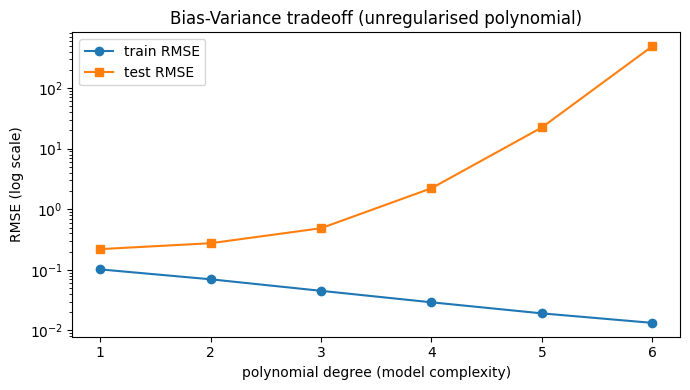

In [22]:
plt.figure(figsize=(7, 4))
plt.plot(list(degrees), train_rmse, "o-", label="train RMSE")
plt.plot(list(degrees), test_rmse, "s-", label="test RMSE")
plt.yscale("log")
plt.xlabel("polynomial degree (model complexity)")
plt.ylabel("RMSE (log scale)")
plt.title("Bias-Variance tradeoff (unregularised polynomial)")
plt.legend()
plt.tight_layout()
plt.show()

### bias-variance curve:

- Low degree (1-2): train and test error are both fairly high and close - the model
  is too simple to capture the degradation pattern (high bias / underfitting).
- High degree (4-6): train error keeps falling while test error explodes (up to
  RMSE 490 at degree 6) - the model fits noise and extrapolates wildly on unseen
  batteries (high variance / overfitting).

best model on test: Random Forest


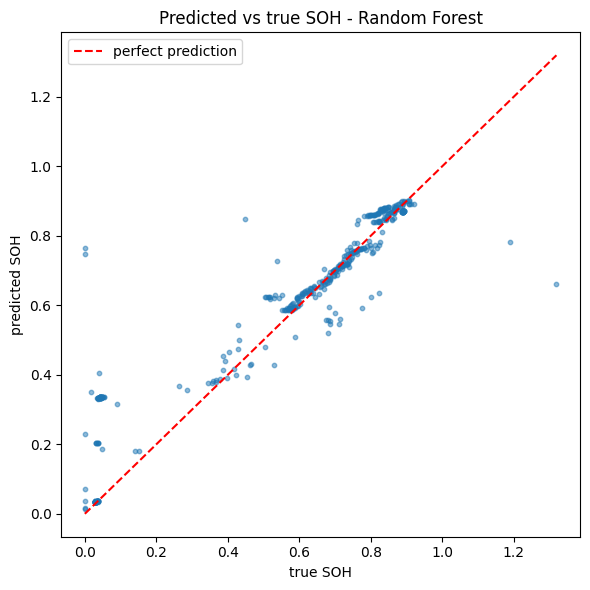

In [23]:
fitted = {"Linear": linear, "Ridge": ridge, "Polynomial": poly, "SVR": svr, "Random Forest": rf}
best_name = max(fitted, key=lambda m: r2_score(y_test, fitted[m].predict(X_test)))
best_model = fitted[best_name]
y_pred_test = best_model.predict(X_test)
print("best model on test:", best_name)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_test, s=10, alpha=0.5)
lims = [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())]
plt.plot(lims, lims, "r--", label="perfect prediction")
plt.xlabel("true SOH"); plt.ylabel("predicted SOH")
plt.title("Predicted vs true SOH - %s" % best_name)
plt.legend(); plt.tight_layout(); plt.show()

## Results

In [24]:
results_df = pd.DataFrame(results).set_index("model")
print(results_df.round(4))

               CV_RMSE  test_RMSE  test_MAE  test_MAPE  test_MaxErr  test_R2
model                                                                       
Linear          0.2835     0.2471    0.1160        inf       0.9996   0.4096
Ridge           0.0950     0.2662    0.1205        inf       0.9106   0.3147
Polynomial      0.1344     0.2199    0.1446        inf       0.7959   0.5323
SVR             0.0602     0.1604    0.0706        inf       0.6426   0.7512
Random Forest   0.0805     0.1231    0.0618        inf       0.7645   0.8535


## Feature importance for Random Forest

top 10 features:
ambient_temperature          0.3906
Voltage_measured_last        0.2778
n_measurements               0.1641
Temperature_measured_last    0.0329
Voltage_measured_std         0.0253
Time_mean                    0.0192
Current_load_mean            0.0148
Voltage_load_mean            0.0144
Temperature_measured_std     0.0109
cycle_number                 0.0105
dtype: float64


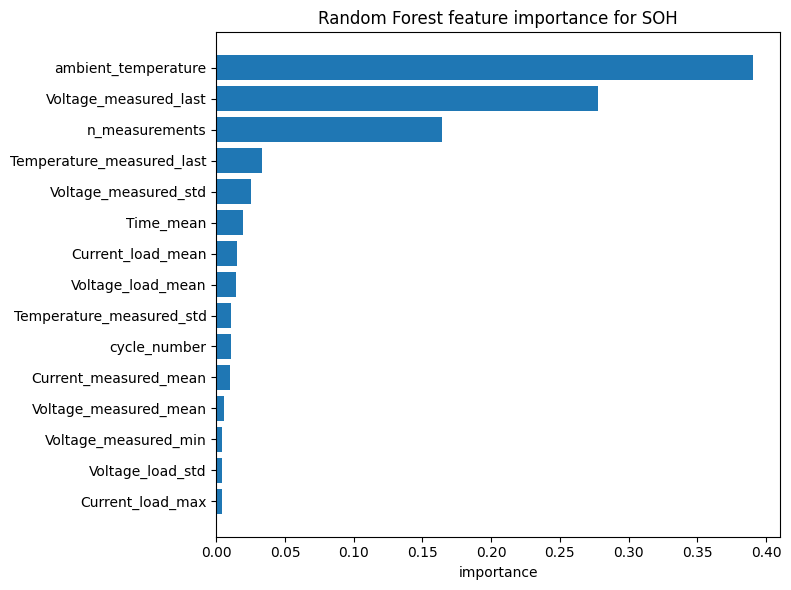

In [25]:
importance = pd.Series(rf.feature_importances_, index=cols).sort_values(ascending=False)
print("top 10 features:")
print(importance.head(10).round(4))

top = importance.head(15)
plt.figure(figsize=(8, 6))
plt.barh(top.index[::-1], top.values[::-1])
plt.xlabel("importance")
plt.title("Random Forest feature importance for SOH")
plt.tight_layout()
plt.show()

In [30]:
df_sorted = df.sort_values(["battery_id", "cycle_number"]).reset_index(drop=True)
Xc = df_sorted[cols].to_numpy(dtype=float)
yc = df_sorted["SOH"].to_numpy()

is_train = np.zeros(len(df_sorted), dtype=bool)
bids = df_sorted["battery_id"].to_numpy()
for b in np.unique(bids):
    idx = np.where(bids == b)[0]
    cut = int(len(idx) * 0.7)
    is_train[idx[:cut]] = True

best_model.fit(Xc[is_train], yc[is_train])
pred_c = best_model.predict(Xc[~is_train])
print("Random Forest | RMSE=%.4f | MAE=%.4f | R2=%.4f"
     % ( mean_squared_error(yc[~is_train], pred_c) ** 0.5,
         mean_absolute_error(yc[~is_train], pred_c),
         r2_score(yc[~is_train], pred_c)))

Random Forest | RMSE=0.0653 | MAE=0.0323 | R2=0.8900
